# Portfolio Lab — EUR investor study

Run top to bottom after package installation. All calculations and safeguards live in portfolio_lab. No prices or FX are forward-filled.

In [1]:
from dataclasses import replace
from pathlib import Path
from IPython.display import display, Image
from portfolio_lab.config import load_config, configure_universe, with_max_weights
from portfolio_lab.data import load_market_data, study_coverage
from portfolio_lab.leverage import add_leverage
from portfolio_lab.metrics import compute_asset_metrics
from portfolio_lab.optimization import optimize_frontier, compare_investor_constraints, sharpe_weight_profile
from portfolio_lab.plotting import plot_frontier, plot_drawdown, plot_weight_profile, allocation_summary
from portfolio_lab.reporting import format_weights, write_review_outputs
from portfolio_lab.bootstrap import bootstrap_frontier

project_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


## User configuration
Select display names, registered tickers and leverage below. Financial metadata lives in `src/portfolio_lab/assets.py`. Run All after every change.

In [2]:
# Total-return series only; common history starts 2000-12-29 (MSCI World is the latest start).
assets = {
    "Apple": "AAPL",                    # Yahoo adjusted close (dividends reinvested)
    "Nasdaq 100": "QQQ",                # ETF, adjusted close (dividends reinvested)
    "MSCI World": "MSCI:990100:NETR",   # official MSCI World Net Total Return index (ETF history too short)
    "S&P 500": "^SP500TR",              # S&P 500 Total Return index
    "Dow Jones": "DIA",                 # ETF, adjusted close (dividends reinvested)
    "Gold": "GC=F",                     # gold pays no income: price change = total return (futures proxy)
    "Coca-Cola": "KO",                  # adjusted close (dividends reinvested)
}

# {} or None = no leverage. Example: {"Apple": 1.5, "Nasdaq 100": 2.0}
leveraged_assets = {}

config = configure_universe(load_config(project_dir), assets, leveraged_assets)
# Optional study overrides:
# config = replace(config, risk_free_rate=0.02, frontier_points=75)


## Market data and provenance

Adjusted equity prices are a reinvestment proxy. Gross-return indices incorporate gross dividends. Gold futures quotations are not an investable total-return benchmark.

In [3]:
data = load_market_data(config)
display(data.provenance)
display(data.fx_sample)
display(study_coverage(data, config))


,Provider,Symbol,Source detail,Instrument / benchmark,Return type,Native currency,Converted to,FX provider,FX series used,FX convention,...,Raw observations,Raw missing observations,FX missing on observed sessions,EUR observations,Final common start,Final common end,Final common observations,Distributions,Limitation,Reference
Asset,,,,,,,,,,,,,,,,,,,,,
Apple,Yahoo Finance,AAPL,,Primary US equity,Adjusted price,USD,EUR,FRED,DEXUSEU,USD per EUR,...,11544,0,4625,6919,2000-12-29,2026-10-02,6403,Yahoo split/dividend adjustment; reinvestment ...,"Adjusted prices are a vendor proxy, not an ind...",
Nasdaq 100,Yahoo Finance,QQQ,,Invesco QQQ ETF; Nasdaq-100 exposure proxy,Adjusted price,USD,EUR,FRED,DEXUSEU,USD per EUR,...,6935,0,61,6874,2000-12-29,2026-10-02,6403,Yahoo dividend/split adjustments; distribution...,Exact Nasdaq-100 TR unavailable from tested Ya...,https://www.invesco.com/qqq-etf/en/home.html
S&P 500,Yahoo Finance,^SP500TR,,S&P 500 Total Return index,Gross Return,USD,EUR,FRED,DEXUSEU,USD per EUR,...,9761,0,2842,6919,2000-12-29,2026-10-02,6403,Gross dividends reinvested by index methodology,,https://www.spglobal.com/spdji/en/indices/equi...
Dow Jones,Yahoo Finance,DIA,,State Street SPDR Dow Jones Industrial Average...,Adjusted price,USD,EUR,FRED,DEXUSEU,USD per EUR,...,7221,0,302,6919,2000-12-29,2026-10-02,6403,Yahoo dividend/split adjustments; distribution...,Exact Dow Jones TR unavailable from tested Yah...,https://www.ssga.com/us/en/individual/etfs/sta...
Gold,Yahoo Finance,GC=F,,Yahoo continuous COMEX gold futures quotation,Price Return,USD,EUR,FRED,DEXUSEU,USD per EUR,...,6548,83,60,6488,2000-12-29,2026-10-02,6403,No dividends; quoted futures price changes only,Not spot gold or an investable futures total-r...,
MSCI World,MSCI,MSCI:990100:NETR,MSCI index code 990100; variant NETR (Net Tota...,"MSCI World Index (index code 990100), Net Tota...",Net Total Return,USD,EUR,FRED,DEXUSEU,USD per EUR,...,6721,0,264,6457,2000-12-29,2026-10-02,6403,Net dividends reinvested according to MSCI ind...,Official index rather than ETF prices; exclude...,https://www.msci.com/indexes/index/990100/msci...
Europe,Yahoo Finance,IEV,,iShares Europe ETF; developed European equities,Adjusted price,USD,EUR,FRED,DEXUSEU,USD per EUR,...,6584,0,59,6525,2000-12-29,2026-10-02,6403,Yahoo dividend/split adjustments; distribution...,Tracks European developed equities through the...,https://www.ishares.com/us/products/239736/IEV
US Real Estate,Yahoo Finance,IYR,,iShares U.S. Real Estate ETF; US real estate e...,Adjusted price,USD,EUR,FRED,DEXUSEU,USD per EUR,...,6612,0,59,6553,2000-12-29,2026-10-02,6403,Yahoo dividend/split adjustments; distribution...,US real estate exposure rather than global rea...,https://www.ishares.com/us/products/239520/ish...


,USD value,EURUSD,Computed EUR value
Date,,,
2000-12-29,0.222453,0.9388,0.236955
2001-01-02,0.222453,0.9465,0.235027
2001-01-03,0.244885,0.9473,0.258509
2001-01-04,0.255167,0.9448,0.270075
2001-01-05,0.244885,0.9535,0.256828


{'common_start': '2000-12-29',
 'common_end': '2026-10-02',
 'common_observations': 6403,
 'latest_raw_asset_start': '2000-12-29',
 'raw_start_limiting_assets': ['MSCI World'],
 'earliest_raw_asset_end': '2026-10-02',
 'raw_end_limiting_assets': ['Apple',
  'Nasdaq 100',
  'S&P 500',
  'Dow Jones',
  'Gold',
  'MSCI World',
  'Europe',
  'US Real Estate'],
 'latest_eur_asset_start': '2000-12-29',
 'eur_start_limiting_assets': ['MSCI World'],
 'start_limiting_series': ['MSCI World'],
 'fx_start': '1999-01-04',
 'first_common_date_delayed_by_calendar': False}

## Daily-reset synthetic assets

Reset on every native underlying session, then translate NAV into EUR with unlevered FX. Compound before sampling common dates.

In [4]:
prices, leverage_diagnostics = add_leverage(data.common, data.native, data.fx, config)
display(leverage_diagnostics)

""


## Asset performance in EUR

In [5]:
stats = compute_asset_metrics(prices, config.trading_days, config.risk_free_rate, config.calendar_days_per_year)
display(stats)

,CAGR,Mean return annualized,Volatility annualized,Max Drawdown,Sharpe,Calmar
Asset,,,,,,
Apple,0.318994,0.345146,0.358460,-0.596244,0.962857,0.535006
Gold,0.103907,0.114373,0.167943,-0.369335,0.681022,0.281334
Dow Jones,0.078214,0.095746,0.196807,-0.533748,0.486497,0.146538
Nasdaq 100,0.103772,0.133724,0.259265,-0.721441,0.515780,0.143840
S&P 500,0.083341,0.102029,0.204052,-0.590313,0.500015,0.141182
MSCI World,0.067256,0.079655,0.165037,-0.536444,0.482648,0.125374
US Real Estate,0.068858,0.102866,0.265212,-0.734202,0.387865,0.093786
Europe,0.044389,0.066653,0.212339,-0.590018,0.313898,0.075234


## Growth frontier and volatility ceilings

Constant weights, long-only; rebalance at each common observation. Leveraged versions replace their underlying in the configured universe.

In [6]:
optimization = optimize_frontier(prices, config)
print(f"Covariance estimator: {optimization.covariance_estimator}; "
      f"expected-return estimator: {optimization.expected_return_estimator}")
display(optimization.summary)
display(format_weights(optimization.weights))
display(allocation_summary(optimization.weights, config.allocation_display_threshold))
display(optimization.dominance)

,CAGR,Mean return annualized,Volatility,Max Drawdown,Sharpe,Calmar,Success,Solver status,Status,Risk ceiling
Portfolio,,,,,,,,,,
Minimum Volatility,0.092296,0.0967,0.119705,-0.308548,0.807822,0.299129,True,0,Optimization terminated successfully,NaN
Maximum CAGR,0.318994,0.345146,0.35846,-0.596244,0.962857,0.535006,True,0,Optimization terminated successfully,NaN
Maximum Sharpe,0.207279,0.206416,0.17521,-0.358289,1.178104,0.578525,True,0,Optimization terminated successfully,NaN
Prudent,0.17174,0.172003,0.15,-0.300639,1.146686,0.571249,True,0,Optimization terminated successfully,0.15
Modéré,0.231819,0.231482,0.2,-0.383747,1.157411,0.604094,True,0,Optimization terminated successfully,0.2
Dynamique,0.294207,0.306624,0.3,-0.526565,1.02208,0.558729,True,0,Optimization terminated successfully,0.3
Agressif,0.318994,0.345146,0.35846,-0.596244,0.962857,0.535006,True,0,Maximum CAGR reached; unused risk allowance,0.4
Très agressif,0.318994,0.345146,0.35846,-0.596244,0.962857,0.535006,True,0,Maximum CAGR reached; unused risk allowance,0.5


,Apple,Nasdaq 100,S&P 500,Dow Jones,Gold,MSCI World,Europe,US Real Estate
Portfolio,,,,,,,,
Minimum Volatility,0.00%,0.00%,0.00%,0.00%,49.10%,50.90%,0.00%,0.00%
Maximum CAGR,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Maximum Sharpe,39.88%,0.00%,0.00%,0.00%,60.12%,0.00%,0.00%,0.00%
Prudent,26.88%,0.00%,0.00%,0.00%,59.21%,12.06%,0.00%,1.85%
Modéré,50.75%,0.00%,0.00%,0.00%,49.25%,0.00%,0.00%,0.00%
Dynamique,83.31%,0.00%,0.00%,0.00%,16.69%,0.00%,0.00%,0.00%
Agressif,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Très agressif,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


Portfolio
Minimum Volatility                        MSCI World 50.9% · Gold 49.1%
Maximum CAGR                                               Apple 100.0%
Maximum Sharpe                                 Gold 60.1% · Apple 39.9%
Prudent               Gold 59.2% · Apple 26.9% · MSCI World 12.1% · ...
Modéré                                         Apple 50.7% · Gold 49.3%
Dynamique                                      Apple 83.3% · Gold 16.7%
Agressif                                                   Apple 100.0%
Très agressif                                              Apple 100.0%
dtype: object

,100% CAGR,100% volatility,Frontier CAGR,Frontier volatility
Asset,,,,
Apple,0.318994,0.358460,0.318994,0.358460
Nasdaq 100,0.103772,0.259265,0.272730,0.259265
S&P 500,0.083341,0.204052,0.235196,0.204052
Dow Jones,0.078214,0.196807,0.229064,0.196807
Gold,0.103907,0.167943,0.198043,0.167943
MSCI World,0.067256,0.165037,0.194061,0.165037
Europe,0.044389,0.212339,0.241745,0.212339
US Real Estate,0.068858,0.265212,0.276122,0.265212


## Optional investor constraints
The results above are the **unconstrained optimum**: what the statistical model prefers (long-only, fully invested, nothing else). Below, `investor_max_weights` adds *personal policy limits* (e.g. at most 10% gold) and shows the best portfolio compatible with them next to the unconstrained one. A limit comes from the investor, not from the model, and the main results above are unchanged. Difference = constrained − unconstrained on the same in-sample history: it is the historical cost (or gain) of the policy, not evidence that either portfolio is statistically superior. Set `investor_max_weights = {}` to skip this section.

In [ ]:
# Investor weight limits: asset -> maximum weight (0 < limit <= 1). {} = no limit.
# Example: gold must not exceed 10% of the portfolio.
investor_max_weights = {"Gold": 0.10}
# Several assets: {"Gold": 0.10, "Apple": 0.30}
# This cell compares the unconstrained optimum with the constrained one. To constrain the whole study
# (main optimization, frontier, targets, charts), add at the end of the User configuration cell:
#     config = with_max_weights(config, {"Gold": 0.10})
if investor_max_weights:
    investor = compare_investor_constraints(prices, config, investor_max_weights)
    investor_cost, investor_weights = investor.formatted()
    display(investor_cost)
    display(investor_weights.loc["Maximum Sharpe"])

## How important is the exact optimal weight?
Descriptive, in-sample sensitivity map: one asset is held at fixed weights (0%–100%) and all other weights are re-optimized for Maximum Sharpe. A flat curve means very different portfolios are nearly equivalent; a sharp peak means moving away from the optimum is expensive. Loss and retained share use the optimizer's own Sharpe objective. The near-optimal ranges are diagnostics only: they are not constraints and are not chosen with out-of-sample results.

In [ ]:
profile_asset = "Gold"  # any optimizer asset
weight_profile = sharpe_weight_profile(prices, config, profile_asset)
display(weight_profile.formatted(step=0.05))
display(weight_profile.near_optimal)
profile_figure = plot_weight_profile(weight_profile, investor_max_weights.get(profile_asset))

## Charts

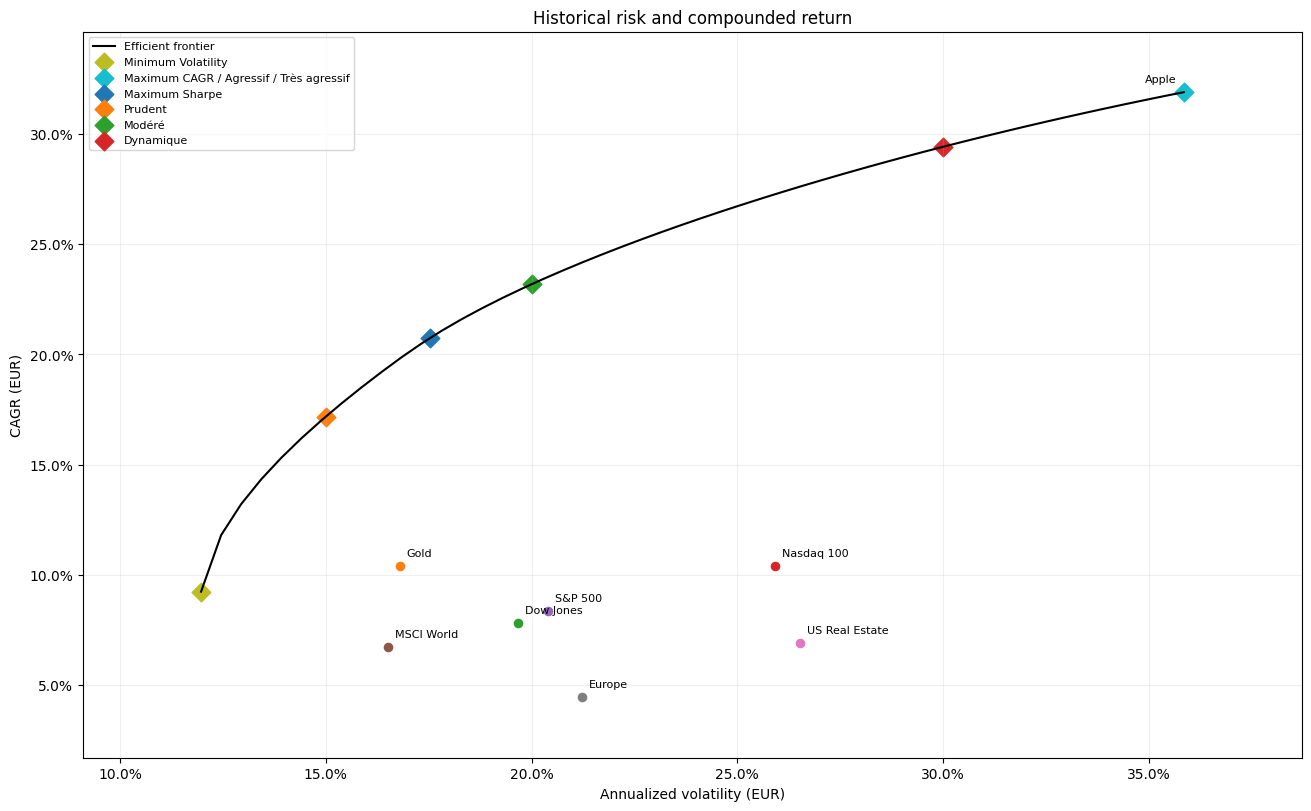

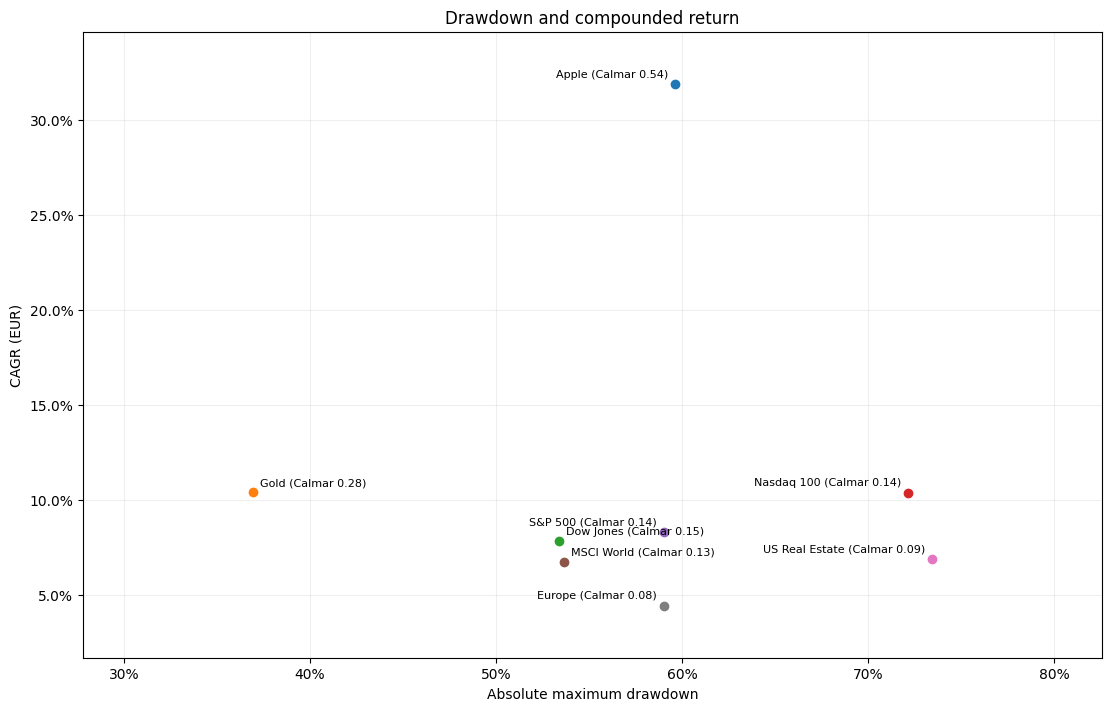

In [7]:
frontier_figure = plot_frontier(stats, optimization)
drawdown_figure = plot_drawdown(stats)

## Bootstrap uncertainty (in-sample)
How much does the *estimated* optimum move when the historical sample is perturbed? Daily return rows are resampled with a stationary block bootstrap (Politis–Romano; expected block length from Politis–White / Patton–Politis–White), and the engine re-estimates the frontier and Maximum Sharpe with the configured estimators in every replication. This differs from the near-optimal map above (how flat the objective is around one estimate) and from the walk-forward (out-of-sample). The shaded area is a *bootstrap uncertainty band*, not a guarantee; settings are fixed and not tuned on results. `bootstrap_replications = 0` skips it.

In [ ]:
bootstrap_replications = 500  # 0 = skip; ~30 s on all CPUs
bootstrap_band_level = 0.80   # 0.80 or 0.95
if bootstrap_replications:
    frontier_bootstrap = bootstrap_frontier(prices, config, replications=bootstrap_replications, seed=0)
    display(frontier_bootstrap.summary())
    display(frontier_bootstrap.formatted_weights())  # Maximum Sharpe weights across replications
    bootstrap_figure = plot_frontier(stats, optimization, band=frontier_bootstrap.band(bootstrap_band_level))

## Export evidence and validate numerical results

{'portfolio_weight_sums': {'Minimum Volatility': 1.0,
  'Maximum CAGR': 1.0,
  'Maximum Sharpe': 1.0,
  'Prudent': 1.0,
  'Modéré': 1.0,
  'Dynamique': 1.0,
  'Agressif': 1.0,
  'Très agressif': 1.0,
  'Frontier 0': 1.0,
  'Frontier 1': 1.0,
  'Frontier 2': 1.0,
  'Frontier 3': 1.0,
  'Frontier 4': 1.0,
  'Frontier 5': 1.0,
  'Frontier 6': 1.0,
  'Frontier 7': 1.0,
  'Frontier 8': 1.0,
  'Frontier 9': 1.0,
  'Frontier 10': 1.0,
  'Frontier 11': 1.0,
  'Frontier 12': 1.0,
  'Frontier 13': 1.0,
  'Frontier 14': 1.0,
  'Frontier 15': 1.0,
  'Frontier 16': 1.0,
  'Frontier 17': 1.0,
  'Frontier 18': 1.0,
  'Frontier 19': 1.0,
  'Frontier 20': 1.0,
  'Frontier 21': 1.0,
  'Frontier 22': 1.0,
  'Frontier 23': 1.0000000000000002,
  'Frontier 24': 1.0,
  'Frontier 25': 1.0,
  'Frontier 26': 1.0,
  'Frontier 27': 1.0,
  'Frontier 28': 0.9999999999999999,
  'Frontier 29': 1.0,
  'Frontier 30': 1.0,
  'Frontier 31': 1.0,
  'Frontier 32': 1.0,
  'Frontier 33': 1.0,
  'Frontier 34': 0.9999999999999

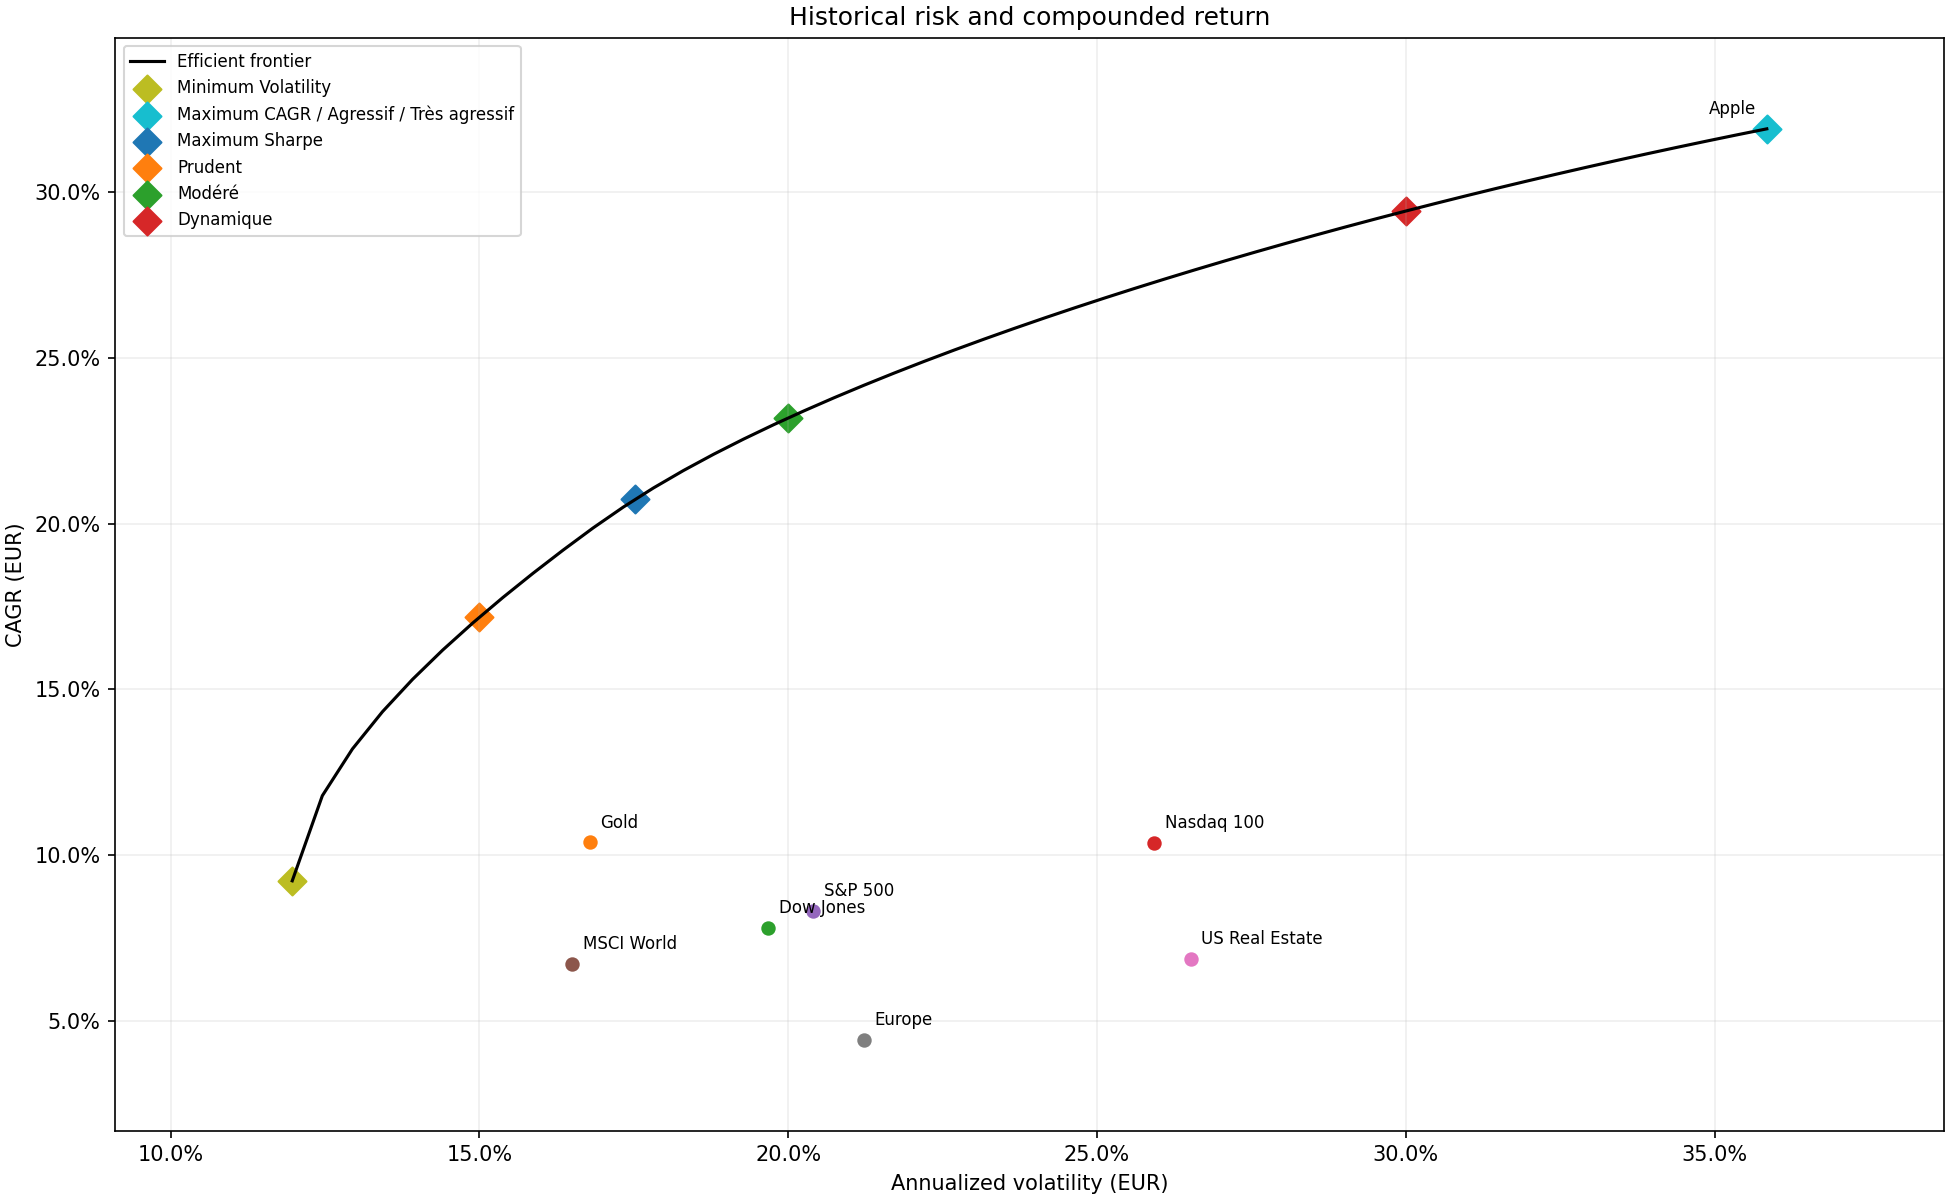

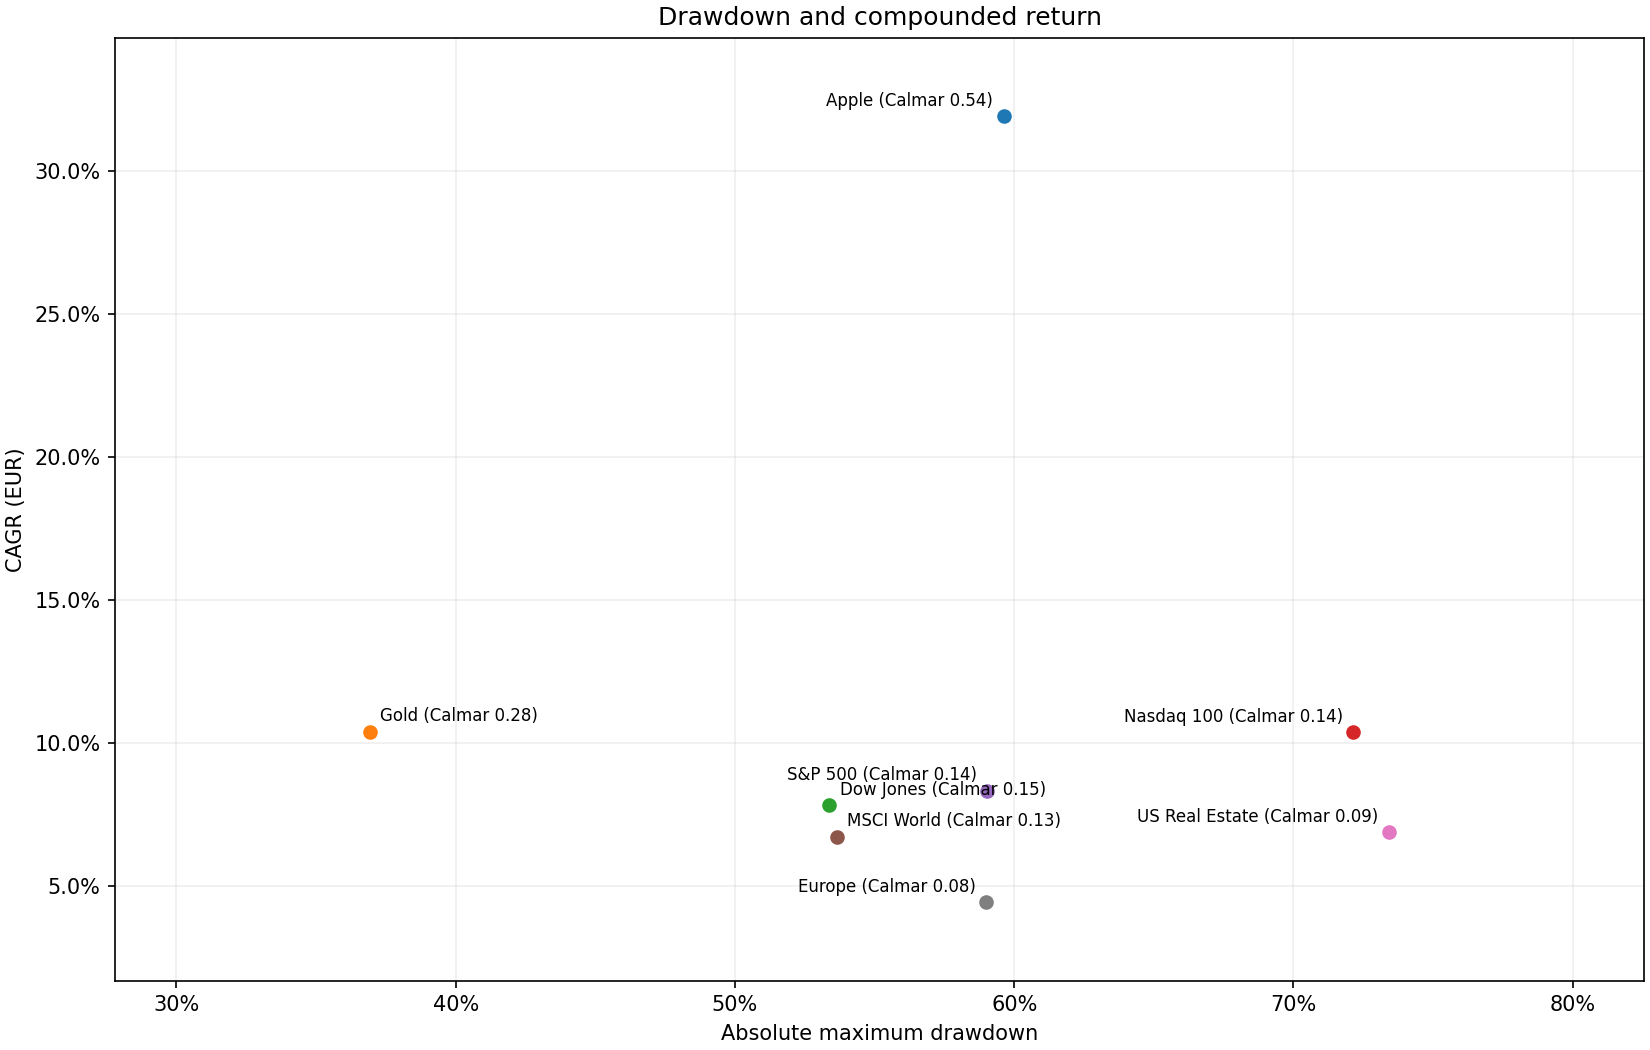

In [8]:
sanity = write_review_outputs(data, prices, stats, leverage_diagnostics, optimization, config)
frontier_figure.savefig(config.output_dir / "frontier.png", dpi=150)
drawdown_figure.savefig(config.output_dir / "drawdown.png", dpi=150)
display(sanity)
display(Image(filename=str(config.output_dir / "frontier.png")))
display(Image(filename=str(config.output_dir / "drawdown.png")))


In [9]:
import yfinance as yf

df = yf.Ticker("EUNL.DE").history(
    period="max",
    interval="1d",
    auto_adjust=False,
)

print(df.index.min())
print(df.index.max())
print(len(df))

2009-09-25 00:00:00+02:00
2026-10-07 00:00:00+02:00
4324
